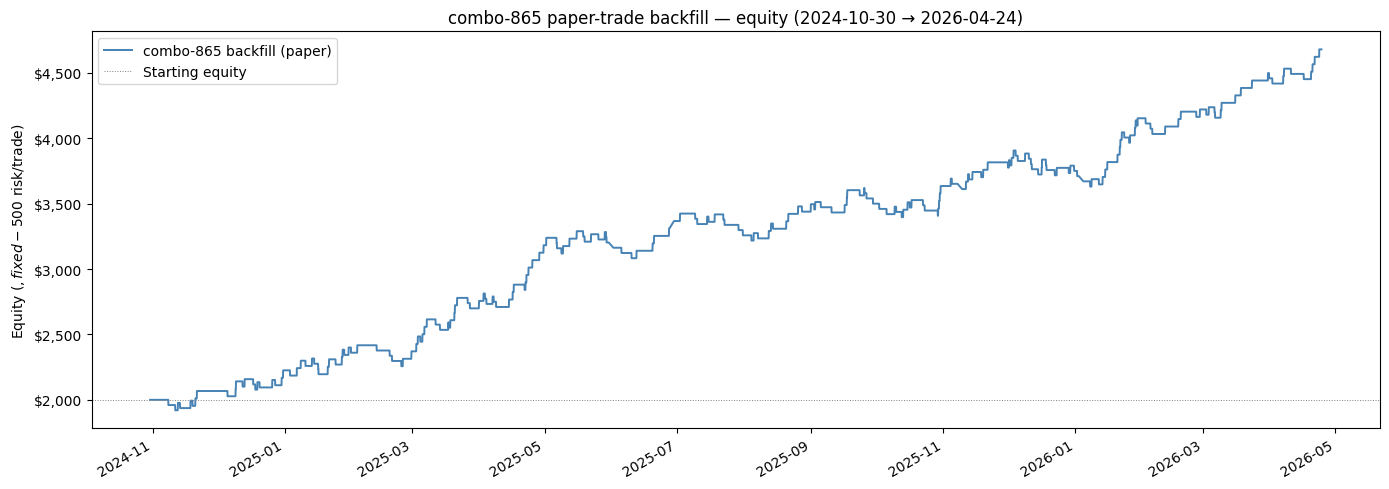

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

ec = pd.read_csv("equity_curve.csv", parse_dates=["time"])
meta = json.load(open("metadata.json"))
START_EQ = meta["STARTING_EQUITY"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ec["time"], ec["equity"], color="steelblue", lw=1.4, label="combo-865 backfill (paper)")
ax.axhline(START_EQ, color="gray", lw=0.7, linestyle=":", label="Starting equity")
ax.set_title(f"combo-865 paper-trade backfill — equity ({meta['bars_first'][:10]} → {meta['bars_last'][:10]})", fontsize=12)
ax.set_ylabel("Equity ($, fixed-$500 risk/trade)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


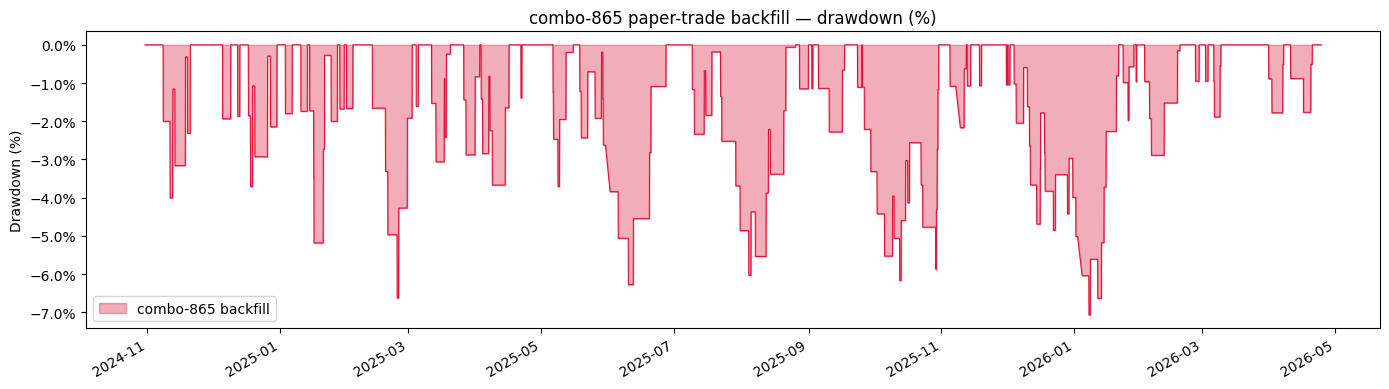

In [2]:
eq_vals = ec["equity"].values
eq_peak = np.maximum.accumulate(eq_vals)
dd_pct = (eq_vals - eq_peak) / eq_peak * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(ec["time"], dd_pct, 0, alpha=0.35, color="crimson", label="combo-865 backfill")
ax.plot(ec["time"], dd_pct, color="crimson", lw=0.8)
ax.set_title("combo-865 paper-trade backfill — drawdown (%)", fontsize=12)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.1f}%"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [3]:

from IPython.display import display

trades = pd.read_csv("trades.csv", parse_dates=["entry_time", "exit_time"])

# Strategy metrics (this run)
n_days = (ec["time"].iloc[-1] - ec["time"].iloc[0]).days
years = max(n_days / 365.25, 1e-9)
final_eq = ec["equity"].iloc[-1]
total_ret_pct = (final_eq / START_EQ - 1) * 100
ann_ret_pct = ((final_eq / START_EQ) ** (365 / max(n_days, 1)) - 1) * 100
max_dd_pct = dd_pct.min()
n_trades = len(trades)
n_wins = trades["label_win"].sum()
win_rate = n_wins / n_trades * 100 if n_trades else 0.0
mean_pnl = trades["net_pnl_dollars"].mean() if n_trades else 0.0
std_pnl = trades["net_pnl_dollars"].std() if n_trades else 0.0
ann_sharpe = (mean_pnl / std_pnl) * np.sqrt(n_trades / years) if std_pnl > 0 else 0.0
exit_counts = trades["exit_reason"].value_counts().to_dict()
total_friction = trades["friction_dollars"].sum() if n_trades else 0.0
total_gross = trades["gross_pnl_dollars"].sum() if n_trades else 0.0

# Probe 2 reference (historical, signed at a49f370)
probe2_ref = {
    "n_trades": 220,
    "win_rate_pct": 53.18,
    "net_sharpe": 2.89,
    "annualized_dollars": 124896.33,
    "max_dd_pct": -14.53,
}

rows = [
    ("n_trades",           f"{n_trades:,}",                   f"{probe2_ref['n_trades']:,}"),
    ("Win rate",           f"{win_rate:.2f}%",                f"{probe2_ref['win_rate_pct']:.2f}%"),
    ("Annualized Sharpe",  f"{ann_sharpe:.3f}",               f"{probe2_ref['net_sharpe']:.3f}"),
    ("Total return",       f"{total_ret_pct:+.2f}%",          "—"),
    ("Annualized return",  f"{ann_ret_pct:+.2f}%",            "—"),
    ("Max drawdown",       f"{max_dd_pct:.2f}%",              f"{probe2_ref['max_dd_pct']:.2f}%"),
    ("Total gross PnL",    f"${total_gross:+,.2f}",           "—"),
    ("Total friction",     f"${total_friction:,.2f}",         "—"),
    ("Final equity",       f"${final_eq:,.2f}",               "—"),
]
df_metrics = pd.DataFrame(rows, columns=["Metric", "This backfill", "Probe 2 reference (1h test)"])
display(df_metrics)
print(f"Exit reasons: {exit_counts}")


,Metric,This backfill,Probe 2 reference (1h test)
0,n_trades,226,220
1,Win rate,53.54%,53.18%
2,Annualized Sharpe,3.026,2.890
3,Total return,+133.97%,—
4,Annualized return,+77.63%,—
5,Max drawdown,-7.07%,-14.53%
6,Total gross PnL,"$+4,035.45",—
7,Total friction,"$1,356.00",—
8,Final equity,"$4,679.45",—


Exit reasons: {'take_profit': 121, 'stop': 105}


In [4]:

mc = json.load(open("monte_carlo.json"))

if "note" in mc:
    print(mc["note"])
else:
    rows = []
    # Keys match src.reporting.run_monte_carlo output (reviewer C4 fix).
    if "max_drawdown" in mc:
        d = mc["max_drawdown"]
        rows.append(("Max DD p50 / p90 / p95 / p99 / worst",
                     f"${d.get('p50','?'):,.0f} / ${d.get('p90','?'):,.0f} / ${d.get('p95','?'):,.0f} / ${d.get('p99','?'):,.0f} / ${d.get('worst','?'):,.0f}"))
    if "var_trade_pnl" in mc:
        rows.append(("Trade-level VaR(5%)", f"${mc['var_trade_pnl']:,.2f}"))
    if "cvar_trade_pnl" in mc:
        rows.append(("Trade-level CVaR(5%)", f"${mc['cvar_trade_pnl']:,.2f}"))
    if "risk_of_ruin_prob" in mc:
        rows.append(("Risk of ruin (DD ≥ 50%)", f"{mc['risk_of_ruin_prob']:.4f}"))
    if "permutation_test" in mc:
        pt = mc["permutation_test"]
        rows.append(("Permutation test p-value (WR vs break-even)",
                     f"{pt.get('p_value','?')}  (sig@.05={pt.get('significant_05','?')}, sig@.01={pt.get('significant_01','?')})"))
    df_mc = pd.DataFrame(rows, columns=["Risk metric", "Value"])
    display(df_mc)


,Risk metric,Value
0,Max DD p50 / p90 / p95 / p99 / worst,"$327 / $487 / $556 / $708 / $1,098"
1,Trade-level VaR(5%),$-40.04
2,Trade-level CVaR(5%),$-40.04
3,Risk of ruin (DD ≥ 50%),0.0004
4,Permutation test p-value (WR vs break-even),"? (sig@.05=True, sig@.01=True)"


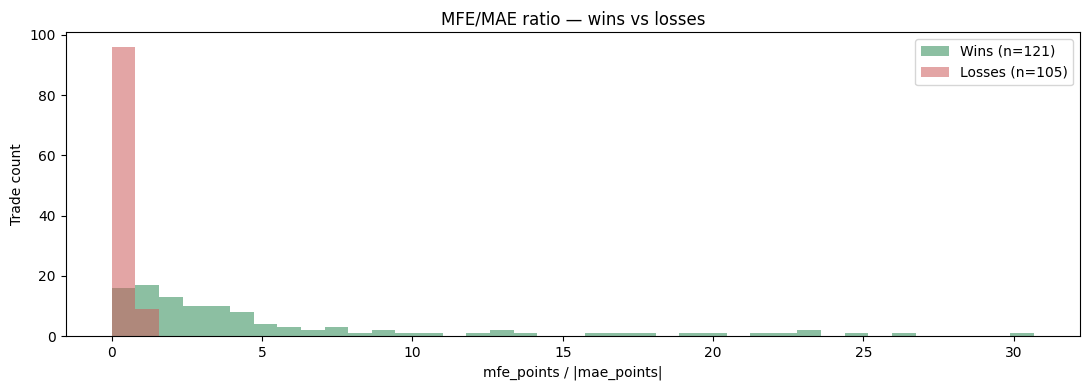

In [5]:
trades = pd.read_csv("trades.csv", parse_dates=["entry_time", "exit_time"])
if len(trades) == 0:
    print("No trades — skipping Track A plots.")
else:
    wins = trades[trades["label_win"]]
    losses = trades[~trades["label_win"]]
    fig, ax = plt.subplots(figsize=(11, 4))
    ratio = trades["mfe_mae_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    ratio_w = wins["mfe_mae_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    ratio_l = losses["mfe_mae_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    bins = np.linspace(0, max(5, ratio.quantile(0.95) if len(ratio) else 5), 40)
    ax.hist(ratio_w, bins=bins, alpha=0.55, color="seagreen", label=f"Wins (n={len(wins)})")
    ax.hist(ratio_l, bins=bins, alpha=0.55, color="indianred", label=f"Losses (n={len(losses)})")
    ax.set_title("MFE/MAE ratio — wins vs losses")
    ax.set_xlabel("mfe_points / |mae_points|")
    ax.set_ylabel("Trade count")
    ax.legend()
    plt.tight_layout()
    plt.show()


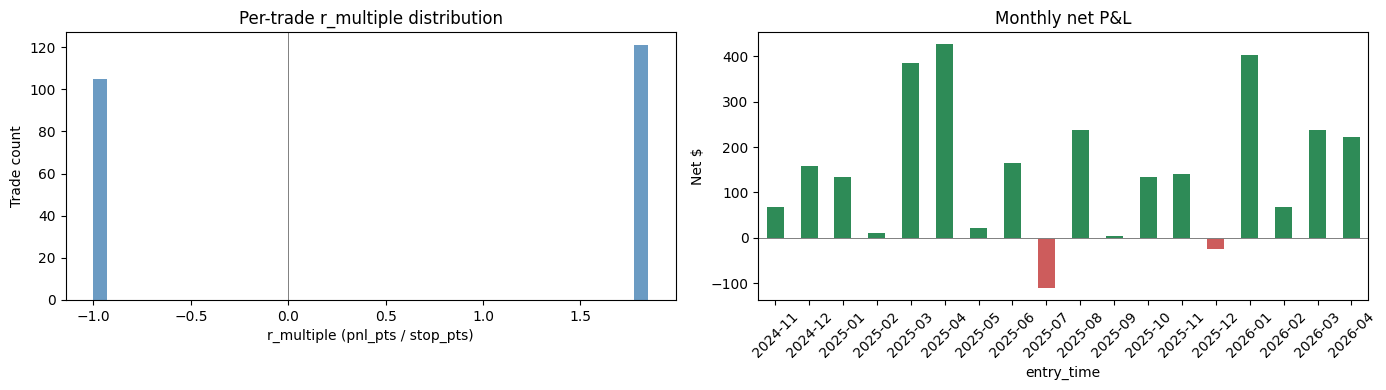

In [6]:
if len(trades) == 0:
    print("No trades — skipping r-multiple plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(trades["r_multiple"], bins=40, color="steelblue", alpha=0.8)
    axes[0].axvline(0, color="gray", lw=0.7)
    axes[0].set_title("Per-trade r_multiple distribution")
    axes[0].set_xlabel("r_multiple (pnl_pts / stop_pts)")
    axes[0].set_ylabel("Trade count")

    monthly = trades.set_index("entry_time")["net_pnl_dollars"].resample("ME").sum()
    monthly.plot(ax=axes[1], kind="bar", color=["seagreen" if v >= 0 else "indianred" for v in monthly])
    axes[1].axhline(0, color="gray", lw=0.7)
    axes[1].set_title("Monthly net P&L")
    axes[1].set_ylabel("Net $")
    axes[1].set_xticklabels([d.strftime("%Y-%m") for d in monthly.index], rotation=45)
    plt.tight_layout()
    plt.show()


In [7]:

def _row_color(row):
    if row["label_win"]:
        return ["background-color: #e6f4e8"] * len(row)
    if row["net_pnl_dollars"] < 0:
        return ["background-color: #fbe6e6"] * len(row)
    return [""] * len(row)

cols = ["trade_id","entry_time","exit_time","side","entry_fill_price","exit_price",
        "stop_pts","tp_pts","r_multiple","net_pnl_dollars","cumulative_net_pnl_dollars",
        "exit_reason","mfe_mae_ratio","label_win"]
view = trades[cols].copy()
view["entry_time"] = view["entry_time"].dt.strftime("%Y-%m-%d %H:%M")
view["exit_time"]  = view["exit_time"].dt.strftime("%Y-%m-%d %H:%M")
styled = view.style.apply(_row_color, axis=1).format({
    "entry_fill_price": "{:.2f}",
    "exit_price": "{:.2f}",
    "stop_pts": "{:.2f}",
    "tp_pts": "{:.2f}",
    "r_multiple": "{:+.2f}",
    "net_pnl_dollars": "${:+,.2f}",
    "cumulative_net_pnl_dollars": "${:+,.2f}",
    "mfe_mae_ratio": "{:.2f}",
})
display(styled)


,trade_id,entry_time,exit_time,side,entry_fill_price,exit_price,stop_pts,tp_pts,r_multiple,net_pnl_dollars,cumulative_net_pnl_dollars,exit_reason,mfe_mae_ratio,label_win
0,1,2024-11-08 07:00,2024-11-08 07:00,long,21182.75,21165.73,17.02,31.44,-1.00,$-40.04,$-40.04,stop,0.48,False
1,2,2024-11-11 11:00,2024-11-11 11:00,long,21203.25,21186.23,17.02,31.44,-1.00,$-40.04,$-80.07,stop,0.21,False
2,3,2024-11-12 15:00,2024-11-12 17:00,short,21185.50,21154.06,17.02,31.44,+1.85,$+56.89,$-23.19,take_profit,3.02,True
3,4,2024-11-13 17:00,2024-11-13 17:00,long,21167.00,21149.98,17.02,31.44,-1.00,$-40.04,$-63.22,stop,0.40,False
4,5,2024-11-18 12:00,2024-11-18 12:00,short,20661.25,20629.81,17.02,31.44,+1.85,$+56.89,$-6.34,take_profit,8.73,True
5,6,2024-11-19 11:00,2024-11-19 11:00,short,20669.75,20686.77,17.02,31.44,-1.00,$-40.04,$-46.37,stop,0.68,False
6,7,2024-11-20 18:00,2024-11-20 18:00,short,20753.75,20722.31,17.02,31.44,+1.85,$+56.89,$+10.52,take_profit,22.95,True
7,8,2024-11-21 11:00,2024-11-21 11:00,long,20732.75,20764.19,17.02,31.44,+1.85,$+56.89,$+67.40,take_profit,3.52,True
8,9,2024-12-05 15:00,2024-12-05 15:00,long,21475.50,21458.48,17.02,31.44,-1.00,$-40.04,$+27.37,stop,0.03,False
9,10,2024-12-09 06:00,2024-12-09 08:00,long,21615.75,21647.19,17.02,31.44,+1.85,$+56.89,$+84.25,take_profit,1.00,True
